In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import io, filters, measure, draw, color
from ipywidgets import interact, IntSlider
from pathlib import Path

def show_video(x, cmap=None):
    def f(i):
        plt.imshow(x[i], cmap=cmap)
    interact(f, i=IntSlider(min=0,max=len(x)-1, step=1, value=0))

frames_path = Path("frames")

# create the array of frames as gray
frames = [io.imread(f, as_gray=True) for f in frames_path.iterdir() if f.is_file()]

# show frames as video
show_video(frames, 'gray')

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

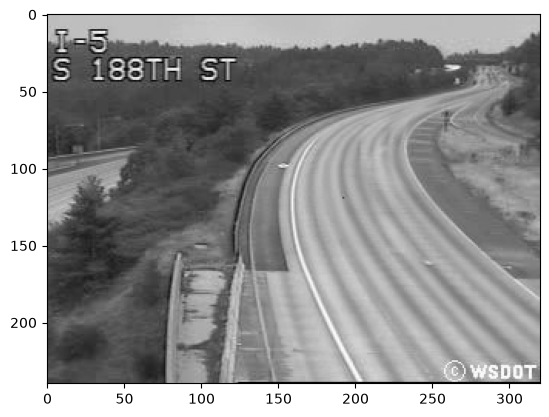

In [57]:
# remove background
stack = np.stack(frames, axis=0)
background = np.mean(stack, axis=0)
plt.imshow(background, cmap='gray')

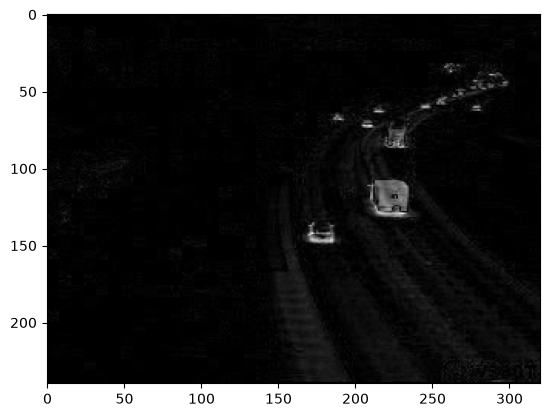

In [58]:
abs_dif = []
# calculate absolute difference of background and first frame
for frame in frames:
        abs_dif.append(abs(frame - background))
plt.imshow(abs_dif[0], cmap='gray')

In [59]:
# otsu's method for absolute difference threshold

# show_video(frames - binary_image, 'gray')
binary_mask = []
for i in range(len(frames)):
    optimal_thresh = filters.threshold_otsu(abs_dif[i])
    binary_mask.append(abs_dif[i] > optimal_thresh)

show_video(binary_mask, 'gray')
    

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

In [ ]:
# apply bounding box around each car
for i in range(len(frames)):
    labels = measure.label(binary_mask[i])
    regions = measure.regionprops(labels)

    for props in regions:
        minr, minc, maxr, maxc = props.bbox
        maxr -= 1
        maxc -= 1

        rr_line, cc_line = draw.rectangle_perimeter((minr, minc), (maxr, maxc), shape=frames[i].shape)
        frames[i][rr_line, cc_line] = 1.0
show_video(frames, 'gray')


interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

In [ ]:
# apply bounding box around each car
for i in range(len(frames)):
    labels = measure.label(binary_mask[i])
    regions = measure.regionprops(labels)

    for props in regions:
        minr, minc, maxr, maxc = props.bbox
        maxr -= 1
        maxc -= 1

        rr_line, cc_line = draw.rectangle_perimeter((minr, minc), (maxr, maxc), shape=frames[i].shape)
        frames[i][rr_line, cc_line] = 1.0
show_video(frames, 'gray')